In [1]:
from getpass import getuser # Libaray to copy things
from pathlib import Path # Object oriented libary to deal with paths
import os
from tempfile import NamedTemporaryFile, TemporaryDirectory # Creating temporary Files/Dirs
from subprocess import run, PIPE
import sys
 
import dask # Distributed data libary
from dask_jobqueue import SLURMCluster # Setting up distributed memories via slurm
from distributed import Client, progress, wait # Libaray to orchestrate distributed resources
import xarray as xr # Libary to work with labeled n-dimensional data and dask

In [2]:
# Set some user specific variables
scratch_dir = Path('/scratch') / getuser()[0] / getuser() # Define the users scratch dir
# Create a temp directory where the output of distributed cluster will be written to, after this notebook
# is closed the temp directory will be closed
dask_tmp_dir = TemporaryDirectory(dir=scratch_dir, prefix='PostProc')
cluster = SLURMCluster(memory='400GiB',
                       cores=72,
                       project='mh0731',
                       walltime='1:00:00',
                       queue='compute',
                       name='PostProc',
                   #    scheduler_options={'dashboard_address': ':12435'},
                       local_directory=dask_tmp_dir.name,
                       job_extra=[f'-J PostProc', 
                                  f'-D {dask_tmp_dir.name}',
                                  f'--begin=now',
                                  f'--output={dask_tmp_dir.name}/LOG_cluster.%j.o',
                                  f'--output={dask_tmp_dir.name}/LOG_cluster.%j.o'
                                 ],
                       interface='ib0')
cluster.scale(jobs=1)
dask_client = Client(cluster)

/home/m/m300948/.conda/envs/JUPYTER_MODULE/lib/python3.9/site-packages/dask_jobqueue/core.py:255: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/home/m/m300948/.conda/envs/JUPYTER_MODULE/lib/python3.9/site-packages/dask_jobqueue/slurm.py:49: FutureWarning: project has been renamed to account as this kwarg was used wit -A option. You are still using it (please also check config files). If you did not set account yet, project will be respected for now, but it will be removed in a future release. If you already set account, project is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/home/m/m300948/.conda/envs/JUPYTER_MODULE/l

In [3]:
from getpass import getuser # Libaray to copy things
from tempfile import NamedTemporaryFile, TemporaryDirectory 

# calculation
import metpy.calc as mpcalc

# scipy
from scipy import stats
from scipy.ndimage import measurements
from scipy import ndimage
from scipy.optimize import curve_fit

# for plot
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# basic
from pathlib import Path # Object oriented libary to deal with paths
import netCDF4 as nc
import numpy as np # Pythons standard array library
import xarray as xr # Libary to work with labeled n-dimensional data
import glob
import os

#metpy
import metpy.calc as mpcalc
from metpy.units import units

In [4]:
def contourf(data, vmin, vmax, cmap, extend, title):
    fig = plt.figure(figsize=[8,10],facecolor='w')
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

    ax.set_extent([-80,-40,-19,10])
    ax.coastlines('50m',linewidth=0.8)
    gl = ax.gridlines(draw_labels=True, linewidth=1.5, color='gray',
                    xlocs=range(-180,180,20), ylocs=range(-90,90,10), crs=ccrs.PlateCarree())
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style, gl.ylabel_style = {'fontsize': 25}, {'fontsize': 25}
    # manipulate `gridliner` object
    gl.xlabels_top = False
    gl.ylabels_left = False
    gl.xlines = False
    gl.ylines = False

    # define lat and lon
    lats = data.lat
    lons = data.lon

    # Apply the same threshold to both datasets (pr_ctl_mm_hour_mask_q99_counts)
    #m = data.sum('hour').plot(levels=np.linspace(0, 20, 10), extend='max', cmap='YlGnBu', transform=ccrs.PlateCarree())
    #m = ax.pcolormesh(lons,lats,data.sum('hour'),cmap=cmap,vmin=vmin,vmax=vmax,transform=ccrs.PlateCarree())
    m = ax.pcolormesh(lons,lats,data,cmap=cmap,vmin=vmin,vmax=vmax,transform=ccrs.PlateCarree())

    #ax.clabel(a, inline=True, fontsize=20)
    #ax.clabel(b, inline=True, fontsize=20)

    kw = {'levels':[-1], 'colors':['lightgrey'], 'linestyles':['solid']}
    plot_bd = AMZ_BD.plot.contour( 
                    ax=ax,
                    transform=ccrs.PlateCarree(),
                    **kw
                    )
    bounds = np.linspace(vmin, vmax, 11)
    cb = plt.colorbar(m, orientation="horizontal", fraction=0.05, pad=0.10, extend=extend,ticks=bounds, boundaries=bounds)
    cb.ax.tick_params(labelsize=25)
    cb.ax.set_xticklabels(bounds,rotation=270)
    plt.title(title, fontsize='20')
    plt.show()

## Save T, Radiation

_Temperature_

In [5]:
# ctl
tas_ctl_directory = '/scratch/m/m300948/test_04/2mt/'
tas_def_directory = '/scratch/m/m300948/def_100/2mt/'

In [7]:
tas_ctl = xr.open_mfdataset(tas_ctl_directory + 'ctl_tas_*' ,parallel=True, chunks={'time': 1, 'lat': -1, 'lon': -1})['tas']
tas_def = xr.open_mfdataset(tas_def_directory + 'def_tas_*' ,parallel=True, chunks={'time': 1, 'lat': -1, 'lon': -1})['tas']

## Amazon masking

In [8]:
# Masking
dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
AMZ_BD = dset_bd.AMAZON_BIOMES
ABinterp_biome = AMZ_BD.interp(latitude=tas_ctl.lat, longitude=tas_ctl.lon)

In [9]:
tas_ctl_mask = tas_ctl.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
tas_def_mask = tas_def.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [ ]:
tas_ctl_mask_2020 = tas_ctl_mask.where(tas_ctl_mask.time.dt.year == 2020, drop=True).isel(height_2=0)
tas_def_mask_2020 = tas_def_mask.where(tas_def_mask.time.dt.year == 2020, drop=True).isel(height_2=0)

In [11]:
tas_ctl_mask_2021 = tas_ctl_mask.where(tas_ctl_mask.time.dt.year == 2021, drop=True).isel(height_2=0)
tas_def_mask_2021 = tas_def_mask.where(tas_def_mask.time.dt.year == 2021, drop=True).isel(height_2=0)

In [12]:
tas_ctl_mask_2022 = tas_ctl_mask.where(tas_ctl_mask.time.dt.year == 2022, drop=True).isel(height_2=0)
tas_def_mask_2022 = tas_def_mask.where(tas_def_mask.time.dt.year == 2022, drop=True).isel(height_2=0)

In [ ]:
contourf(tas_ctl_mask_2020.isel(time=0), 300, 310, 'YlGnBu', 'max','violent-ctl') # 23500-25500

# Find the range of max and min for each grid and find the highest value

In [13]:
tas_ctl_mask_2020 = tas_ctl_mask_2020.where(tas_ctl_mask_2020 != 0, np.nan)
tas_ctl_mask_2021 = tas_ctl_mask_2021.where(tas_ctl_mask_2021 != 0, np.nan)
tas_ctl_mask_2022 = tas_ctl_mask_2022.where(tas_ctl_mask_2022 != 0, np.nan)

In [14]:
tas_def_mask_2020 = tas_def_mask_2020.where(tas_def_mask_2020 != 0, np.nan)
tas_def_mask_2021 = tas_def_mask_2021.where(tas_def_mask_2021 != 0, np.nan)
tas_def_mask_2022 = tas_def_mask_2022.where(tas_def_mask_2022 != 0, np.nan)

## Total mean average temperature

In [18]:
tas_ctl_mask_2022.mean(dim=('time','lat','lon')).values

array(296.82407, dtype=float32)

In [19]:
tas_def_mask_2022.mean(dim=('time','lat','lon')).values

array(300.57394, dtype=float32)

## Diurnal cycle

In [14]:
tas_ctl_2020_diurnal = tas_ctl_mask_2020.groupby(tas_ctl_mask_2020.time.dt.hour).mean(dim='time').mean(dim=('lat','lon'))
tas_ctl_2021_diurnal = tas_ctl_mask_2021.groupby(tas_ctl_mask_2021.time.dt.hour).mean(dim='time').mean(dim=('lat','lon'))
tas_ctl_2022_diurnal = tas_ctl_mask_2022.groupby(tas_ctl_mask_2022.time.dt.hour).mean(dim='time').mean(dim=('lat','lon'))

In [15]:
tas_def_2020_diurnal = tas_def_mask_2020.groupby(tas_def_mask_2020.time.dt.hour).mean(dim='time').mean(dim=('lat','lon'))
tas_def_2021_diurnal = tas_def_mask_2021.groupby(tas_def_mask_2021.time.dt.hour).mean(dim='time').mean(dim=('lat','lon'))
tas_def_2022_diurnal = tas_def_mask_2022.groupby(tas_def_mask_2022.time.dt.hour).mean(dim='time').mean(dim=('lat','lon'))

findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.


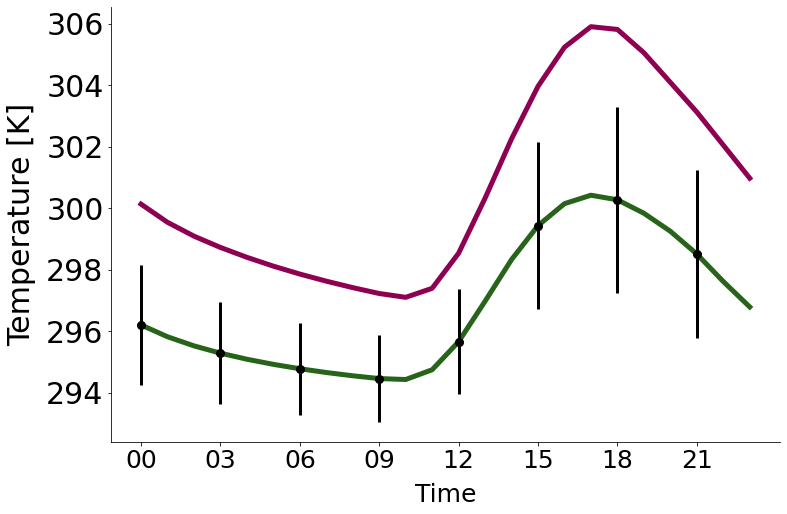

In [42]:
fig, ax = plt.subplots(figsize=(12,8))
# get color from BrBG
cmap = matplotlib.cm.get_cmap('PiYG')
left = cmap(0.0)
right = cmap(1.0)

plt.plot(tas_ctl_diurnal, label='CTL',c=right,linewidth=5)
plt.plot(tas_def_diurnal, label='DEF', c=left,linewidth=5)
#plt.errorbar(diurnal_ts_std_ngc2_mask['time'].dt.hour, diurnal_cycle.values, std_diurnal_cycle.values,  marker='o', markersize='8', linewidth=3, c='black')
#plt.errorbar(diurnal_ts_std_ngc2_mask['time'].dt.hour, tas_ctl_savg_diurnal[::3], std_diurnal_cycle.values, linestyle='', marker='o', markersize='8', linewidth=3, c='black')

plt.errorbar(a, tas_ctl_diurnal[::3], std_diurnal_cycle, linestyle='', marker='o', markersize='8', linewidth=3, c='black')

plt.xticks(fontsize=30)
plt.yticks(fontsize=30,family='Arial')

ax.set_ylabel('Temperature [K]',fontsize=30, labelpad = 10,family='Arial')
ax.set_xlabel('Time',fontsize=25, labelpad = 10)
#plt.xlabel('Difference PR [mm/day]',fontsize=25, labelpad = 20)
plt.xticks([0,3,6,9,12,15,18,21],['00','03','06','09','12','15','18','21'],fontsize=25,family='Arial')

ax.spines[['right', 'top']].set_visible(False)

_MAX_

In [ ]:
# Daily max for all grids
tas_ctl_mask_2020_max = tas_ctl_mask_2020.resample(time='1D').max(dim='time') 
tas_def_mask_2020_max = tas_def_mask_2020.resample(time='1D').max(dim='time')
tas_ctl_mask_2021_max = tas_ctl_mask_2021.resample(time='1D').max(dim='time')
tas_def_mask_2021_max = tas_def_mask_2021.resample(time='1D').max(dim='time')
tas_ctl_mask_2022_max = tas_ctl_mask_2022.resample(time='1D').max(dim='time')
tas_def_mask_2022_max = tas_def_mask_2022.resample(time='1D').max(dim='time')

In [16]:
xarray_names = ['tas_ctl_mask_2020_max','tas_def_mask_2020_max']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_flat[xarray_data_flat == 0] = np.nan
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [19]:
xarray_names = ['tas_ctl_mask_2021_max','tas_def_mask_2021_max']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_flat[xarray_data_flat == 0] = np.nan
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [20]:
xarray_names = ['tas_ctl_mask_2022_max','tas_def_mask_2022_max']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_flat[xarray_data_flat == 0] = np.nan
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [21]:
tas_ctl_mask_max_f = np.concatenate((tas_ctl_mask_2020_max_f, tas_ctl_mask_2021_max_f, tas_ctl_mask_2022_max_f))
tas_def_mask_max_f = np.concatenate((tas_def_mask_2020_max_f, tas_def_mask_2021_max_f, tas_def_mask_2022_max_f))

In [ ]:
import pandas as pd
df1 = pd.DataFrame(tas_ctl_mask_max_f)
df2 = pd.DataFrame(tas_def_mask_max_f)
df1.to_csv('/scratch/m/m300948/tas_ctl_mask_max_f.csv', index=False, header=False)
df2.to_csv('/scratch/m/m300948/tas_def_mask_max_f.csv', index=False, header=False)

_MIN_

In [39]:
# Daily min for all grids
#tas_ctl_mask_2020_min = tas_ctl_mask_2020.resample(time='1D').min(dim='time') 
tas_def_mask_2020_min = tas_def_mask_2020.resample(time='1D').min(dim='time')
#tas_ctl_mask_2021_min = tas_ctl_mask_2021.resample(time='1D').min(dim='time')
tas_def_mask_2021_min = tas_def_mask_2021.resample(time='1D').min(dim='time')
#tas_ctl_mask_2022_min = tas_ctl_mask_2022.resample(time='1D').min(dim='time')
tas_def_mask_2022_min = tas_def_mask_2022.resample(time='1D').min(dim='time')

In [40]:
xarray_names = ['tas_def_mask_2020_min'] # 'tas_ctl_mask_2020_min',
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_flat[xarray_data_flat == 0] = np.nan
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [41]:
xarray_names = ['tas_def_mask_2021_min'] # 'tas_ctl_mask_2021_min',
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_flat[xarray_data_flat == 0] = np.nan
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [42]:
xarray_names = ['tas_def_mask_2022_min'] # 'tas_ctl_mask_2022_min',
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_flat[xarray_data_flat == 0] = np.nan
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [43]:
#tas_ctl_mask_min_f = np.concatenate((tas_ctl_mask_2020_min_f, tas_ctl_mask_2021_min_f, tas_ctl_mask_2022_min_f))
tas_def_mask_min_f = np.concatenate((tas_def_mask_2020_min_f, tas_def_mask_2021_min_f, tas_def_mask_2022_min_f))

In [44]:
import pandas as pd
#df1 = pd.DataFrame(tas_ctl_mask_min_f)
df2 = pd.DataFrame(tas_def_mask_min_f)
#df1.to_csv('/scratch/m/m300948/tas_ctl_mask_min_f.csv', index=False, header=False)
df2.to_csv('/scratch/m/m300948/tas_def_mask_min_f.csv', index=False, header=False)

_Total_

In [15]:
xarray_names = ['tas_ctl_mask_2020','tas_def_mask_2020']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_flat[xarray_data_flat == 0] = np.nan
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [16]:
xarray_names = ['tas_ctl_mask_2021','tas_def_mask_2021']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_flat[xarray_data_flat == 0] = np.nan
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [17]:
xarray_names = ['tas_ctl_mask_2022','tas_def_mask_2022']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_flat[xarray_data_flat == 0] = np.nan
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [18]:
tas_ctl_mask_f = np.concatenate((tas_ctl_mask_2020_f, tas_ctl_mask_2021_f, tas_ctl_mask_2022_f))
tas_def_mask_f = np.concatenate((tas_def_mask_2020_f, tas_def_mask_2021_f, tas_def_mask_2022_f))

In [19]:
import pandas as pd
df1 = pd.DataFrame(tas_ctl_mask_f)
df2 = pd.DataFrame(tas_def_mask_f)
df1.to_csv('/scratch/m/m300948/tas_ctl_mask_total_f.csv', index=False, header=False)
df2.to_csv('/scratch/m/m300948/tas_def_mask_total_f.csv', index=False, header=False)

## load and plot the pdf

In [5]:
import pandas as pd

tas_ctl_mask_max_f = pd.read_csv('/scratch/m/m300948/tas_ctl_mask_max_f.csv', sep=',', header=None)
tas_def_mask_max_f = pd.read_csv('/scratch/m/m300948/tas_def_mask_max_f.csv', sep=',', header=None)

In [6]:
tas_ctl_mask_min_f = pd.read_csv('/scratch/m/m300948/tas_ctl_mask_min_f.csv', sep=',', header=None)
tas_def_mask_min_f = pd.read_csv('/scratch/m/m300948/tas_def_mask_min_f.csv', sep=',', header=None)

In [7]:
tas_ctl_mask_mean_f = pd.read_csv('/scratch/m/m300948/tas_ctl_mask_mean_f.csv', sep=',', header=None)
tas_def_mask_mean_f = pd.read_csv('/scratch/m/m300948/tas_def_mask_mean_f.csv', sep=',', header=None)

In [8]:
tas_ctl_mask_total_f = pd.read_csv('/scratch/m/m300948/tas_ctl_mask_total_f.csv', sep=',', header=None)
tas_def_mask_total_f = pd.read_csv('/scratch/m/m300948/tas_def_mask_total_f.csv', sep=',', header=None)

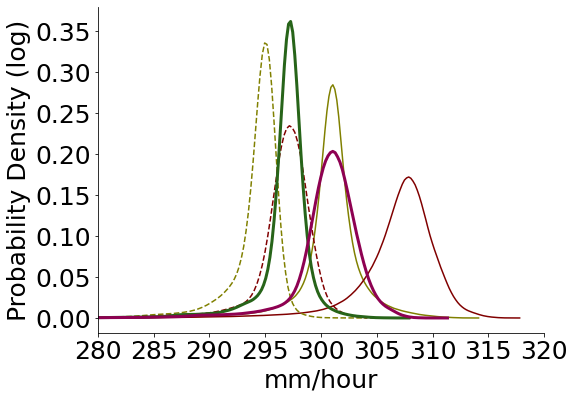

In [11]:
# Normalize the PDF
pdf_ctl_max, bins_ctl_max = np.histogram(tas_ctl_mask_max_f, bins=250, density=True)  # Adjust the number of bins as needed (hist, bins)
pdf_def_max, bins_def_max = np.histogram(tas_def_mask_max_f, bins=250, density=True)  # Adjust the number of bins as needed
pdf_ctl_min, bins_ctl_min = np.histogram(tas_ctl_mask_min_f, bins=250, density=True)  # Adjust the number of bins as needed (hist, bins)
pdf_def_min, bins_def_min = np.histogram(tas_def_mask_min_f, bins=250, density=True)  # Adjust the number of bins as needed
pdf_ctl_mean, bins_ctl_mean = np.histogram(tas_ctl_mask_mean_f, bins=250, density=True)  # Adjust the number of bins as needed (hist, bins)
pdf_def_mean, bins_def_mean = np.histogram(tas_def_mask_mean_f, bins=250, density=True)  # Adjust the number of bins as needed

# Calculate the bin centers
bin_centers_ctl_max = (bins_ctl_max[:-1] + bins_ctl_max[1:]) * 0.5
bin_centers_def_max = (bins_def_max[:-1] + bins_def_max[1:]) * 0.5
bin_centers_ctl_min = (bins_ctl_min[:-1] + bins_ctl_min[1:]) * 0.5
bin_centers_def_min = (bins_def_min[:-1] + bins_def_min[1:]) * 0.5
bin_centers_ctl_mean = (bins_ctl_mean[:-1] + bins_ctl_mean[1:]) * 0.5
bin_centers_def_mean = (bins_def_mean[:-1] + bins_def_mean[1:]) * 0.5

# Plot the PDF
clr = ['darkkhaki', 'darkkhaki', 'darkkhaki', 'thistle', 'thistle', 'thistle'] 
# get color from BrBG
cmap = matplotlib.cm.get_cmap('PiYG')
left = cmap(0.0)
right = cmap(1.0)

fig = plt.figure(figsize=(8, 6))
plt.plot(bin_centers_ctl_max, pdf_ctl_max, label='CTL_max', color='olive', linewidth=1.5)
plt.plot(bin_centers_def_max, pdf_def_max, label='DEF_max', color='maroon', linewidth=1.5)
plt.plot(bin_centers_ctl_min, pdf_ctl_min, label='CTL_min', color='olive', linewidth=1.5, ls='--')
plt.plot(bin_centers_def_min, pdf_def_min, label='DEF_min', color='maroon', linewidth=1.5, ls='--')
plt.plot(bin_centers_ctl_mean, pdf_ctl_mean, label='CTL_mean', color=right, linewidth=3)
plt.plot(bin_centers_def_mean, pdf_def_mean, label='DEF_,mean', color=left, linewidth=3)

# Set labels and title
plt.xlabel('mm/hour', fontsize='25')
plt.ylabel('Probability Density (log)', fontsize='25')
#plt.title('PDF', fontsize='15')
#plt.yscale('log')
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
#plt.xscale('log')
#
plt.xlim(280, 320)
# remove frame on upper and right side
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# add legend
#plt.legend(fontsize=15)

# Display the plot
plt.show()